## Data Visualization

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import scipy.stats as stats
import json

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

#### Structured Data

1. 샘플 데이터프레임을 생성한 후, 데이터의 기본 정보를 출력하는 코드를 작성하세요.

In [2]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)

df.describe()

,나이,연봉
count,5.00000,5.00000
mean,31.60000,5340.00000
std,5.94138,2660.45109
min,25.00000,3500.00000
25%,28.00000,4000.00000
50%,30.00000,4200.00000
75%,35.00000,5000.00000
max,40.00000,10000.00000


2. 샘플 데이터에서 나이가 30 이상이고 연봉이 5000 이하인 사람들만 필터링하는 코드를 작성하세요.

In [3]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

df_filtered = df[(df['나이'] >= 30) & (df['연봉'] <= 5000)]
df_filtered

,이름,나이,직업,연봉,가입일
1,이영희,30,마케터,3500,2019-07-15
2,박민수,35,개발자,5000,2021-01-10
5,정지훈,50,디자이너,4600,2016-04-11


3. 샘플 데이터에서 가입 연도가 2019년 이전인 사람들을 찾아 연봉을 10% 인상한 후, 전체 평균 연봉을 계산하는 코드를 작성하세요.

In [4]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

filtered = df[df['가입일']<'2019-01-01']

# 기존 데이터
df

,이름,나이,직업,연봉,가입일
0,김철수,25,개발자,4000,2020-05-21
1,이영희,30,마케터,3500,2019-07-15
2,박민수,35,개발자,5000,2021-01-10
3,최지현,28,디자이너,4200,2018-11-03
4,홍길동,40,CEO,10000,2017-09-27
5,정지훈,50,디자이너,4600,2016-04-11
6,이지은,22,마케터,3300,2022-03-19


In [5]:
df.loc[df['가입일'] < '2019-01-01', '연봉'] *= 1.1
print("전체 평균 연봉:", df['연봉'].mean())

전체 평균 연봉: 5211.428571428572


In [6]:
# 적용된 데이터
df

,이름,나이,직업,연봉,가입일
0,김철수,25,개발자,4000,2020-05-21
1,이영희,30,마케터,3500,2019-07-15
2,박민수,35,개발자,5000,2021-01-10
3,최지현,28,디자이너,4620,2018-11-03
4,홍길동,40,CEO,11000,2017-09-27
5,정지훈,50,디자이너,5060,2016-04-11
6,이지은,22,마케터,3300,2022-03-19


#### Unstructured Data

1. JSON 형식의 데이터를 직접 생성한 후, Pandas 데이터프레임으로 변환하는 코드를 작성하세요.

In [7]:
import pandas as pd
import json

data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

json_data = json.loads(data)

df = pd.DataFrame(json_data)

print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


2. 아래 샘플 데이터에서 한글과 공백을 제외한 모든 문자를 제거하고, 공백을 하나로 정리하는 코드를 작성하세요.

In [8]:
import re

# 샘플 데이터 (비정형 텍스트)
text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."

# 한글과 공백을 제외한 모든 문자 제거
text = re.sub(r'[^가-힣\s]', '', text)
# 연속 공백을 하나로 정리
text = re.sub(r'\s+', ' ', text).strip()

print(text)

안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다


3. 주어진 텍스트 데이터를 문장 단위로 분리한 후, 각 문장의 단어 개수를 데이터프레임으로 변환하는 코드를 작성하세요.

In [9]:
# 샘플 텍스트 데이터
text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

sentences = text.split('.')

result = []

for sentence in sentences:
    sentence = sentence.strip()
    if sentence:  
        word_count = len(sentence.split())
        result.append({
            "문장": sentence,
            "단어수": word_count
        })

df = pd.DataFrame(result)

df

,문장,단어수
0,자연어 처리는 재미있다,3
1,파이썬과 pandas를 활용하면 편리하다,4
2,데이터 분석은 흥미롭다,3


### 1. Matplotlib

#### 1.1 Bar Chart

1. matplotlib을 활용하여 5개의 카테고리와 각각의 값이 포함된 기본 세로 막대 그래프를 생성하는 코드를 작성하세요.

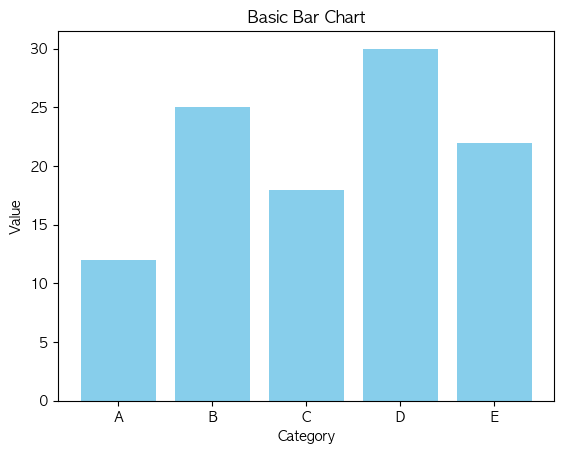

In [10]:
# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

# 막대 그래프 생성
plt.bar(categories, values, color='skyblue')  
plt.xlabel("Category")  
plt.ylabel("Value")  
plt.title("Basic Bar Chart") 

# 그래프 표시
plt.show()  

2. 누적형 막대 그래프를 생성하여, 두 개의 연도별 데이터를 각각 다른 색상으로 누적하여 표현하는 코드를 작성하세요.

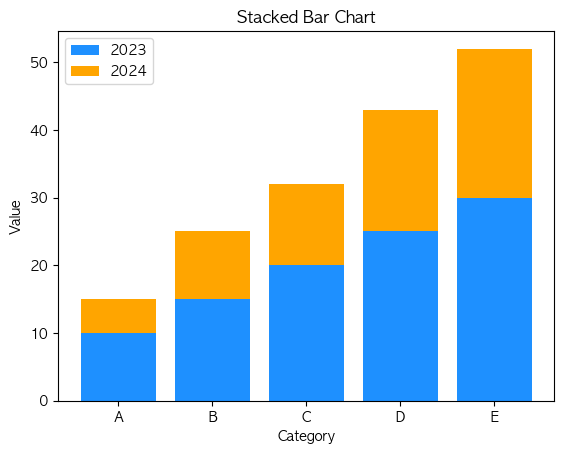

In [11]:
# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

x = np.arange(len(categories))

plt.bar(x, values_2023, color='dodgerblue', label='2023')
plt.bar(x, values_2024, color='orange',bottom=values_2023, label='2024')

plt.xticks(x, categories)
plt.xlabel("Category")  
plt.ylabel("Value")  
plt.title("Stacked Bar Chart")
plt.legend() 

# 그래프 표시
plt.show()  

3. 한 기업의 부서별 연간 성과(2023년 vs 2024년)를 비교하는 그룹형 막대 그래프를 생성하는 코드를 작성하세요.

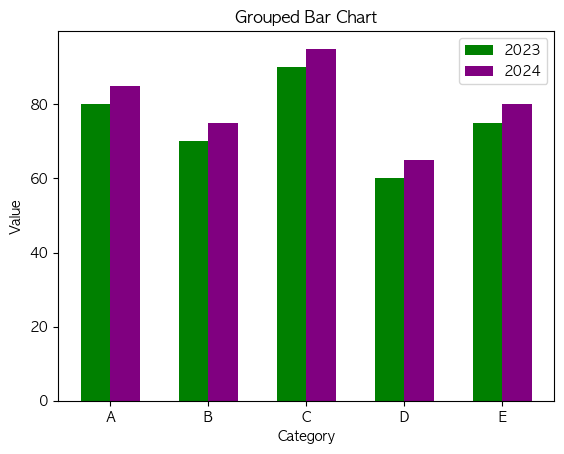

In [12]:
# 샘플 데이터 생성
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

bar_width = 0.3

x = np.arange(len(categories))

plt.bar(x - bar_width/2, performance_2023, width=bar_width, color='green', label='2023')
plt.bar(x + bar_width/2, performance_2024, width=bar_width, color='purple', label='2024')

plt.xticks(x, categories)
plt.xlabel('Category')
plt.ylabel('Value')
plt.title('Grouped Bar Chart')
plt.legend()

plt.show()

#### 1.2 Histogram

1. 정규 분포를 따르는 1000개의 데이터를 생성한 후, 구간을 15개로 설정한 히스토그램을 그리는 코드를 작성하세요.

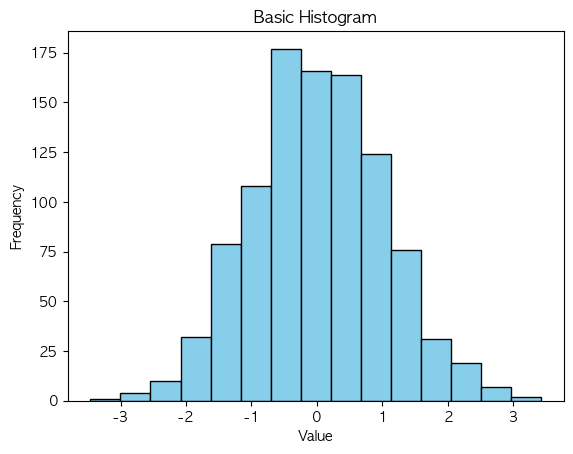

In [13]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)


# 기본 히스토그램 생성
plt.hist(data, bins=15, color='skyblue', edgecolor='black') 
plt.xlabel("Value")      # X축 라벨 설정 (데이터 범위)
plt.ylabel("Frequency")  # Y축 라벨 설정 (빈도)
plt.title("Basic Histogram")  # 그래프 제목 설정

plt.show()

2. 두 개의 서로 다른 정규 분포를 따르는 데이터셋을 생성한 후, 두 히스토그램을 같은 그래프에서 겹쳐서 비교하는 코드를 작성하세요.

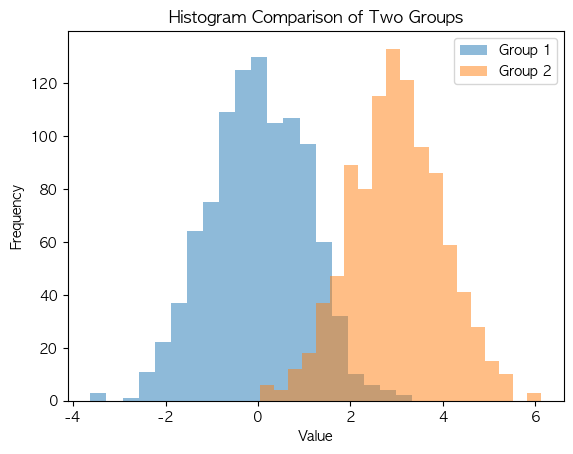

In [14]:
# 첫 번째 데이터셋 (평균 0, 표준편차 1)
data1 = np.random.randn(1000)

# 두 번째 데이터셋 (평균 3, 표준편차 1)
data2 = np.random.randn(1000) + 3


plt.hist(data1, bins=20, alpha=0.5, label='Group 1')
plt.hist(data2, bins=20, alpha=0.5, label='Group 2')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram Comparison of Two Groups")
plt.legend()
plt.show()

3. 한 데이터셋의 누적 히스토그램을 그린 후, X축과 Y축의 적절한 레이블을 설정하는 코드를 작성하세요.

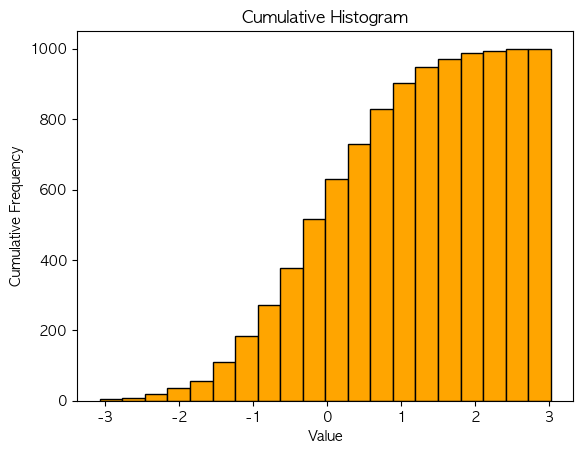

In [15]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, bins=20, cumulative=True, color='orange', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Cumulative Frequency")
plt.title("Cumulative Histogram")
plt.show()

#### 1.3 Scatter Plot

1. 두 개의 리스트 x = [1, 2, 3, 4, 5], y = [3, 1, 4, 5, 2]를 사용하여 산점도를 그리고, X축과 Y축의 라벨을 추가하는 코드를 작성하세요.

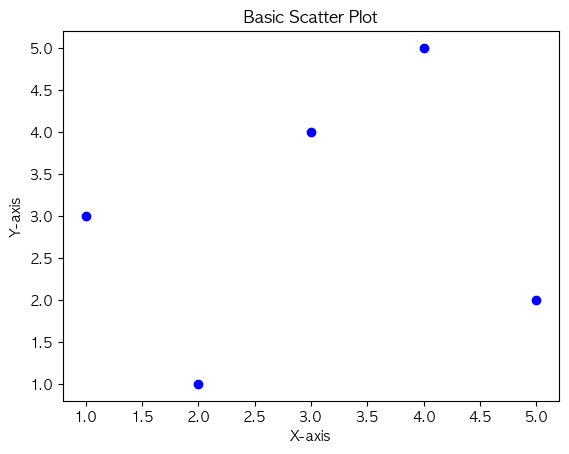

In [16]:
# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]


# 산점도 생성
plt.scatter(x, y, color='blue', marker='o')  # X, Y 좌표에 해당하는 점을 파란색 원으로 표시
plt.xlabel("X-axis")  # X축 라벨 설정
plt.ylabel("Y-axis")  # Y축 라벨 설정
plt.title("Basic Scatter Plot")  # 그래프 제목 설정

# 그래프 표시
plt.show()  # 설정한 내용을 화면에 출력

2. numpy를 활용하여 난수를 생성한 후, 산점도를 그리고 점의 색상과 투명도를 설정하는 코드를 작성하세요.

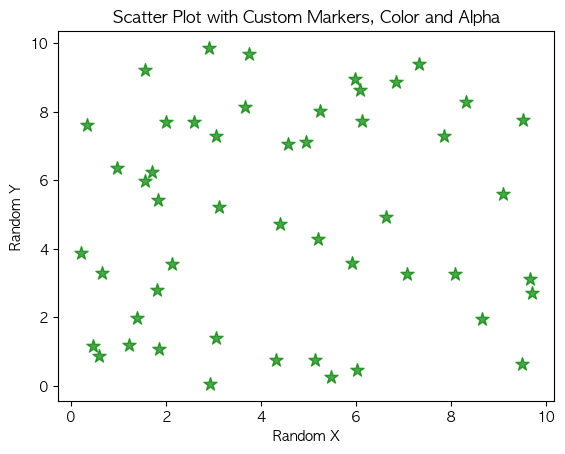

In [17]:
# 난수 데이터 생성
np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개


# 산점도 생성
plt.scatter(x, y,
            color='green',   # 점 색상 설정 (초록색)
            marker='*',      # 점 모양 설정 (삼각형)
            alpha=0.7,       # 점 투명도 설정 (0~1 사이 값)
            s=100)           # 점 크기 설정, (기본값 20, 보통 50~200, 강조하고 싶을 때 300)
plt.xlabel("Random X")  # X축 라벨
plt.ylabel("Random Y")  # Y축 라벨
plt.title("Scatter Plot with Custom Markers, Color and Alpha")  # 그래프 제목 설정

# 그래프 표시
plt.show()  # 설정한 그래프를 출력

3. numpy를 활용하여 세 개의 그룹('A', 'B', 'C')에 속하는 데이터의 산점도를 서로 다른 색상으로 그리는 코드를 작성하세요. 

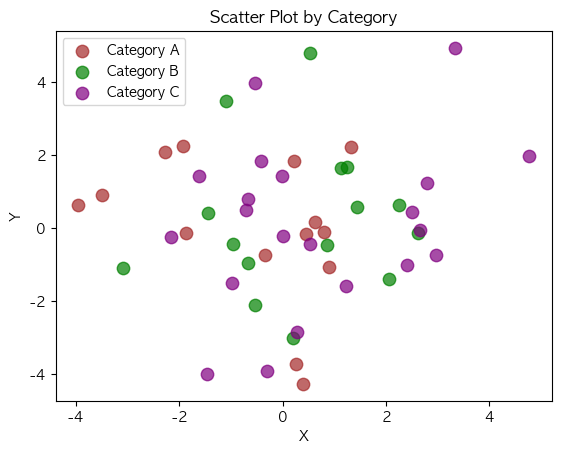

In [18]:
# 데이터 생성
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)


colors = {'A': 'brown', 'B': 'green', 'C': 'purple'}  # 카테고리별 색상 지정

# 산점도 생성
for cat in np.unique(categories):  # 유일한 카테고리 목록 순회
    idx = categories == cat  # 특정 카테고리에 해당하는 데이터 선택
    plt.scatter(x[idx], y[idx],  # 해당 카테고리의 x, y 값만 선택하여 표시
                color=colors[cat],  # 지정한 색상 적용
                label=f'Category {cat}',  # 범례 표시
                alpha=0.7,  # 투명도 적용
                s=80)  # 점 크기 설정

plt.xlabel("X")  # X축 라벨
plt.ylabel("Y")  # Y축 라벨
plt.title("Scatter Plot by Category")  # 그래프 제목 설정
plt.legend()  # 범례 추가

# 그래프 표시
plt.show()  # 그래프 출력

#### 1.4 Box Plot

1. 평균 0, 표준편차 1을 따르는 정규분포 난수 50개를 생성한 후, 해당 데이터를 이용해 기본 박스 플롯을 출력하는 코드를 작성하세요.

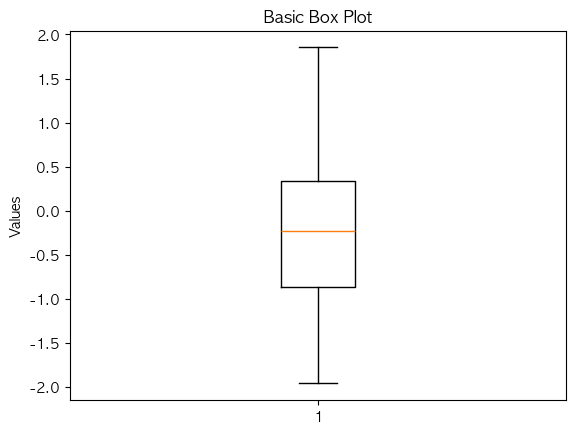

In [19]:
# 정규분포를 따르는 난수 50개 생성
np.random.seed(42)
data = np.random.randn(50)

plt.boxplot(data)
plt.title("Basic Box Plot")
plt.ylabel("Values")

plt.show()

2. 세 개의 그룹(Group A, Group B, Group C) 에 대해 각각 다른 평균을 가지는 데이터를 생성하고, 이를 이용해 다중 박스 플롯을 그리는 코드를 작성하세요.

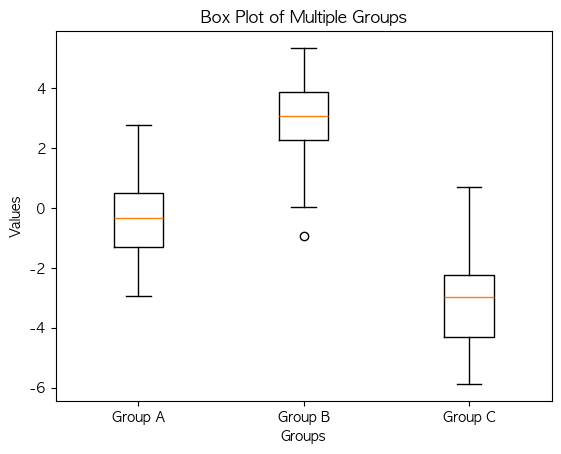

In [20]:
# 랜덤 데이터 생성 (각 그룹별 평균 다르게 설정)
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

# 여러 개의 박스 플롯 생성
plt.boxplot([group_a, group_b, group_c], tick_labels=['Group A', 'Group B', 'Group C'])

# 그래프 설정
plt.xlabel("Groups")  # X축 라벨 설정
plt.ylabel("Values")  # Y축 라벨 설정
plt.title("Box Plot of Multiple Groups")  # 그래프 제목 설정

# 그래프 표시
plt.show()

3. 평균이 **서로 다른 두 개의 그룹(Group X, Group Y)** 을 비교하는 박스 플롯을 그리세요.

단, **이상값을 강조하고, 스타일을 커스터마이징**해야 합니다.

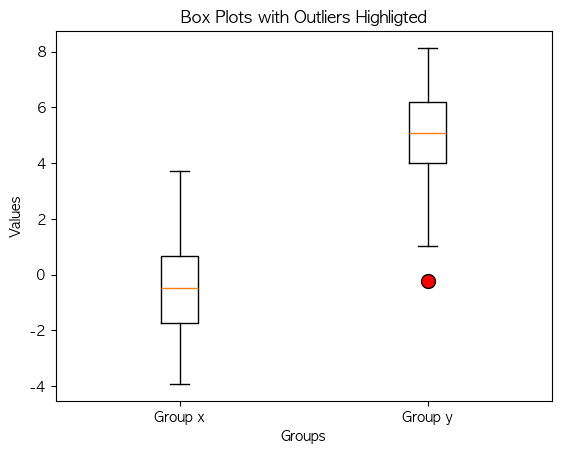

In [21]:
# 랜덤 데이터 생성 (두 그룹의 평균 다르게 설정)
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

plt.boxplot([group_x, group_y], tick_labels=['Group x', 'Group y'], flierprops=dict(marker='o', markerfacecolor='red', markersize=10, linestyle='none'))

# 그래프 설정
plt.title("Box Plots with Outliers Highligted")
plt.xlabel("Groups") 
plt.ylabel("Values") 

plt.show() 

#### 1.5 Advanced Multiple Graphs

1. plt.subplots()를 사용하여 2x1 형태의 서브플롯을 만들고, 첫 번째 서브플롯에는 y = x^2, 두 번째 서브플롯에는 y = x^3을 그리는 코드를 작성하세요.

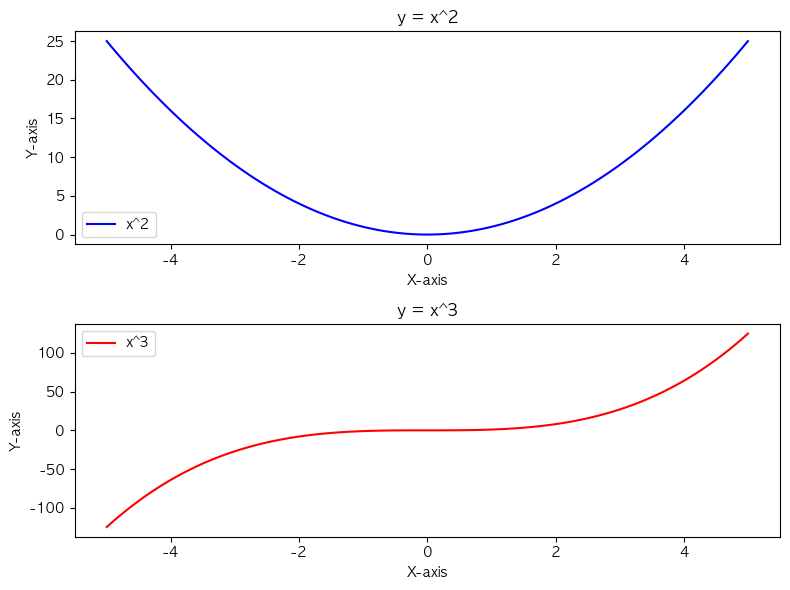

In [22]:
# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱


# 서브플롯 설정 (2행 1열)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))  # 2개의 그래프를 세로로 배치, 크기는 8x6 인치

# 첫 번째 서브플롯 (사인 함수)
axes[0].plot(x, y1, color='b', label='x^2')  # 첫 번째 서브플롯에 사인 그래프 추가 (파란색)
axes[0].set_title("y = x^2")  # 첫 번째 서브플롯 제목 설정
axes[0].set_xlabel("X-axis")  # 첫 번째 서브플롯의 X축 라벨 설정
axes[0].set_ylabel("Y-axis")  # 첫 번째 서브플롯의 Y축 라벨 설정
axes[0].legend()  # 범례 추가

# 두 번째 서브플롯 (코사인 함수)
axes[1].plot(x, y2, color='r', label='x^3')  # 두 번째 서브플롯에 코사인 그래프 추가 (빨간색)
axes[1].set_title("y = x^3")  # 두 번째 서브플롯 제목 설정
axes[1].set_xlabel("X-axis")  # 두 번째 서브플롯의 X축 라벨 설정
axes[1].set_ylabel("Y-axis")  # 두 번째 서브플롯의 Y축 라벨 설정
axes[1].legend()  # 범례 추가

# 전체 레이아웃 조정
plt.tight_layout()  # 그래프 간 간격 자동 조정

# 그래프 출력
plt.show()  # 그래프 화면 출력

2. X축을 공유하는 1행 2열 형태의 서브플롯을 생성하고, 첫 번째 서브플롯에는 정규 분포를 따르는 난수의 히스토그램, 두 번째 서브플롯에는 균등 분포를 따르는 난수의 히스토그램을 그리세요.

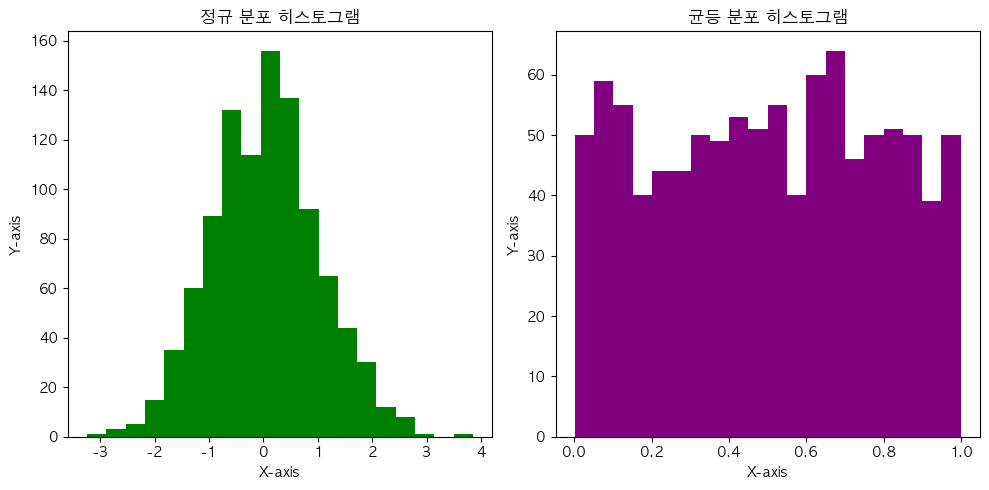

In [23]:
# 데이터 생성
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10, 5))

axes[0].hist(normal_data, bins=20, color="green")
axes[0].set_title("정규 분포 히스토그램")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")

axes[1].hist(uniform_data, bins=20, color="purple")
axes[1].set_title("균등 분포 히스토그램")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")

# 그래프 출력
plt.tight_layout()  # 그래프 간격 자동 조정
plt.show()  # 그래프 화면 출력

3. gridspec을 사용하여 불규칙한 레이아웃의 서브플롯을 생성하고, 각각 선 그래프, 산점도, 막대 그래프, 히스토그램을 그리세요.

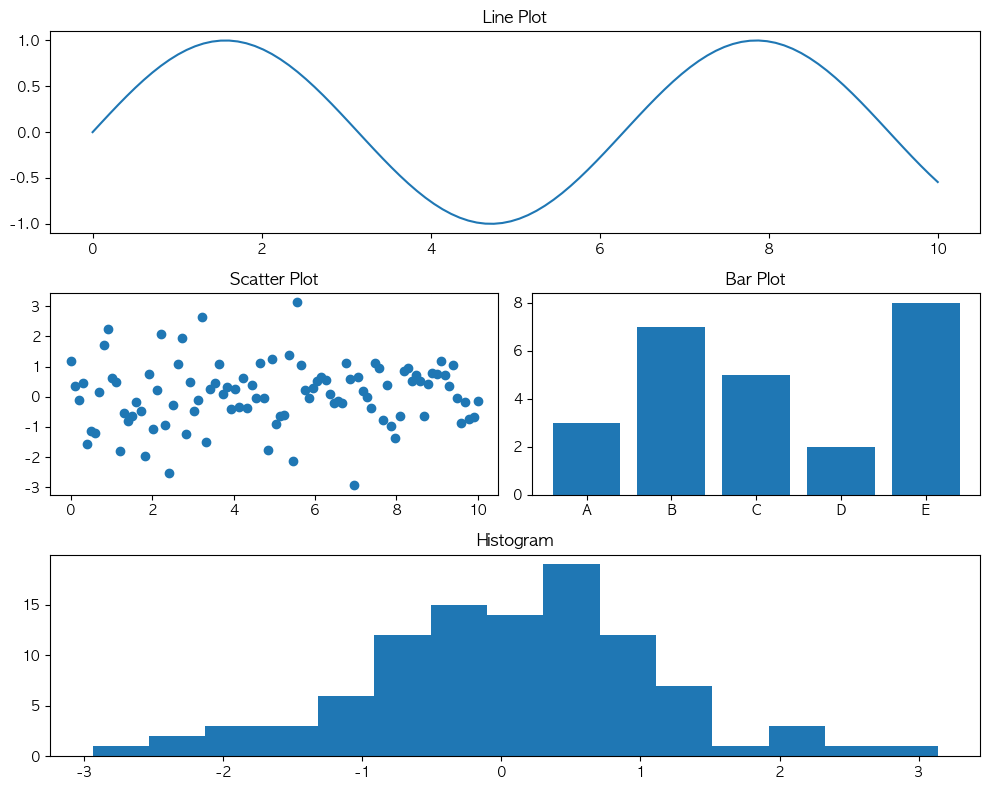

In [24]:
import matplotlib.gridspec as gridspec

# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

# Figure 생성
fig = plt.figure(figsize=(10, 8))

# 3행 2열 GridSpec 생성
gs = gridspec.GridSpec(3, 2)

# 1. 선 그래프 (첫 번째 행 전체 사용)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x, y1)
ax1.set_title('Line Plot')

# 2. 산점도 (두 번째 행 왼쪽)
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(x, y2)
ax2.set_title('Scatter Plot')

# 3. 막대 그래프 (두 번째 행 오른쪽)
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(categories, values)
ax3.set_title('Bar Plot')

# 4. 히스토그램 (세 번째 행 전체 사용)
ax4 = fig.add_subplot(gs[2, :])
ax4.hist(y2, bins=15)
ax4.set_title('Histogram')

# 그래프 간격 조정
plt.tight_layout()

# 출력
plt.show()

#### 1.6 Venn Diagram

1. 두 개의 과일 집합을 정의하고, 두 집합의 차집합(한 집합에만 존재하는 요소)을 출력하는 코드를 작성하세요.

In [25]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

# 차집합 출력
print("A에만 있는 과일 (A - B):", set_A - set_B)
print("B에만 있는 과일 (B - A):", set_B - set_A)

A에만 있는 과일 (A - B): {'사과', '체리'}
B에만 있는 과일 (B - A): {'수박', '포도'}


2. 벤 다이어그램을 그리지 않고, 세 개의 집합을 비교하여 각 집합이 단독으로 가지는 요소 개수와 교집합 개수를 계산하는 코드를 작성하세요.

In [26]:
# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

# 각 집합 단독 요소
only_A = set_A - set_B - set_C
only_B = set_B - set_A - set_C
only_C = set_C - set_A - set_B

# 두 집합 교집합 (세 번째 집합 제외)
AB_only = (set_A & set_B) - set_C
AC_only = (set_A & set_C) - set_B
BC_only = (set_B & set_C) - set_A

# 세 집합 공통 교집합
ABC = set_A & set_B & set_C

print(f"A 단독: {len(only_A)}개 → {only_A}")
print(f"B 단독: {len(only_B)}개 → {only_B}")
print(f"C 단독: {len(only_C)}개 → {only_C}")
print(f"A∩B (C 제외): {len(AB_only)}개 → {AB_only}")
print(f"A∩C (B 제외): {len(AC_only)}개 → {AC_only}")
print(f"B∩C (A 제외): {len(BC_only)}개 → {BC_only}")
print(f"A∩B∩C: {len(ABC)}개 → {ABC}")

A 단독: 2개 → {'사과', '체리'}
B 단독: 1개 → {'포도'}
C 단독: 2개 → {'딸기', '오렌지'}
A∩B (C 제외): 1개 → {'바나나'}
A∩C (B 제외): 0개 → set()
B∩C (A 제외): 1개 → {'수박'}
A∩B∩C: 1개 → {'망고'}


3. **벤 다이어그램을 그리면서, 특정 조건을 만족하는 경우 색상을 다르게 지정하는 코드**를 작성하세요.
- **조건:** 두 개의 집합을 비교할 때, **교집합이 2개 이상이면 노란색, 그렇지 않으면 기본 색상**을 사용하세요.

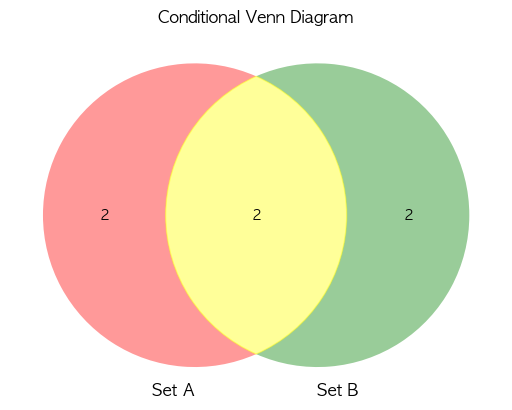

In [27]:
# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

diagram = venn2([set_A, set_B], set_labels=("Set A", "Set B"))

if len(set_A & set_B) >= 2:
    patch = diagram.get_patch_by_id("11")
    if patch:
        patch.set_color("yellow")

plt.title("Conditional Venn Diagram")
plt.show()

### 2. Seaborn

#### 2.1 Categorical Data

  Category  Value
0        A     10
1        A     15
2        B      7
3        B     12
4        C     22
5        C     18
6        C     25
7        A     11
8        B      9
9        C     30


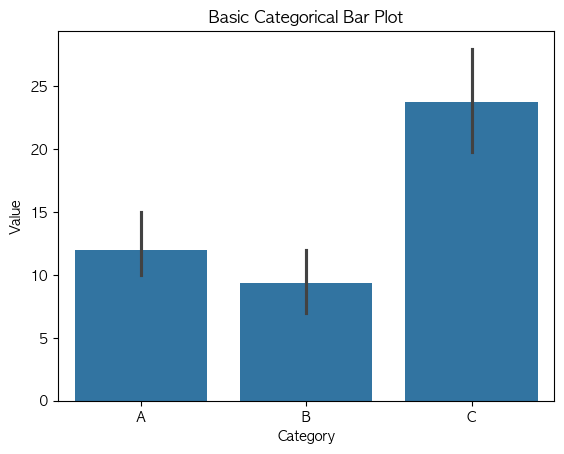

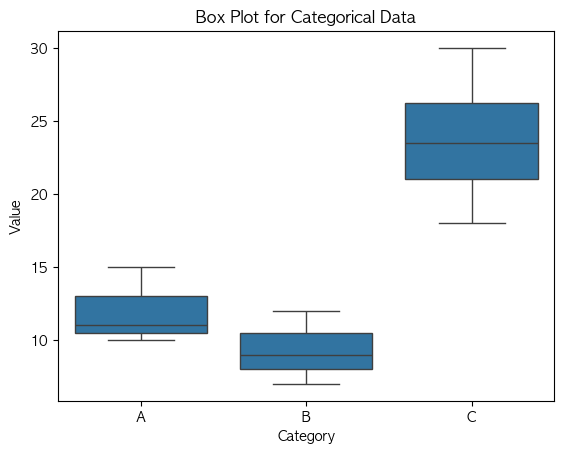

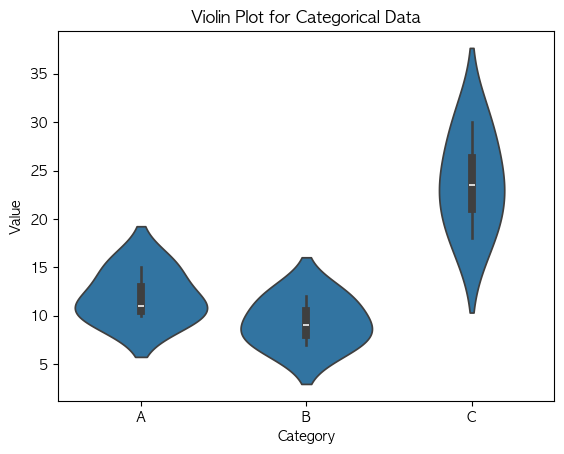

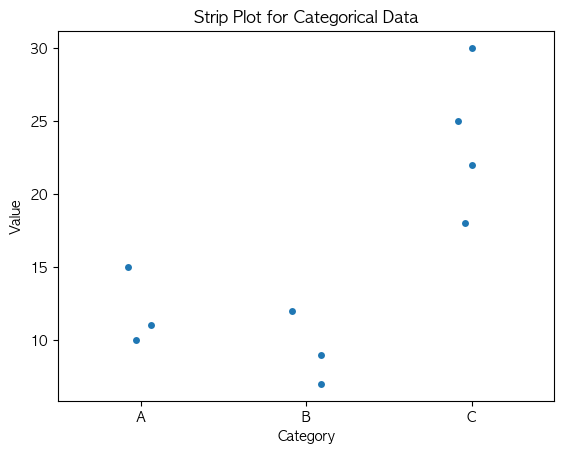

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
	"Category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"], # 범주형 데이터 (A, B, C 그룹),
	"Value": [10, 15, 7, 12, 22, 18, 25, 11, 9, 30] # 각 범주의 값 }) # 데이터 확인 
})

print(data)

## 기본 범주형 데이터 시각화 - 막대그래프
sns.barplot(x="Category", y="Value", data=data)
plt.title("Basic Categorical Bar Plot")
plt.show()

## 범주형 데이터의 분포 시각화 - 박스 플롯
sns.boxplot(x="Category", y="Value", data=data)
plt.title("Box Plot for Categorical Data")
plt.show()

## 범주형 데이터의 밀도 및 분포 시각화 - 바이올린 플롯
sns.violinplot(x="Category", y="Value", data=data)
plt.title("Violin Plot for Categorical Data")
plt.show()

# 범주형 데이터의 개별 데이터 포인트 시각화 (스트립 플롯) 
sns.stripplot(x="Category", y="Value", data=data, jitter=True) # jitter=True: 데이터 포인트가 겹쳐 보이지 않도록 위치를 조금씩 조정, 데이터 값 자체가 변하는 것은 아님 
plt.title("Strip Plot for Categorical Data") 
plt.show()


1. 샘플 데이터를 직접 생성한 후 Seaborn을 활용하여 막대 그래프(bar plot)를 생성하는 코드를 작성하세요.

In [29]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "카테고리": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "값": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})

# 데이터 확인
data

,카테고리,값
0,X,5
1,X,9
2,Y,4
3,Y,6
4,Z,12
5,Z,10
6,Z,14
7,X,7
8,Y,5
9,Z,18


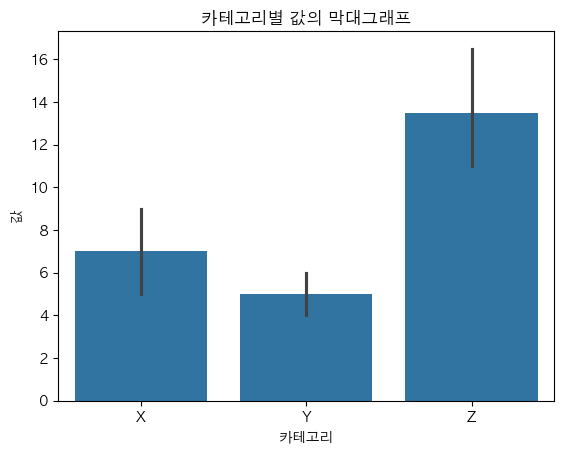

In [30]:
sns.barplot(x="카테고리", y="값", data=data)
plt.title("카테고리별 값의 막대그래프")
plt.show()

2. Seaborn의 sns.boxplot()을 활용하여 범주형 데이터의 분포를 시각화하는 코드를 작성하세요.

In [31]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})

# 데이터 확인
data

,group,score
0,A,65
1,A,70
2,B,55
3,B,60
4,C,90
5,C,85
6,C,95
7,A,72
8,B,58
9,C,88


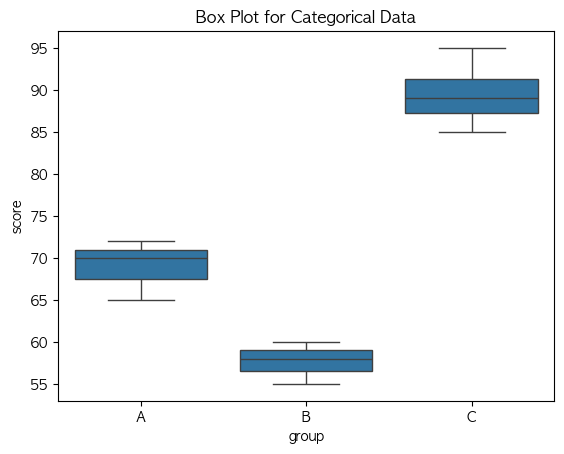

In [32]:
sns.boxplot(x="group", y="score", data=data)
plt.title("Box Plot for Categorical Data")
plt.show()

3. Seaborn의 sns.violinplot()과 sns.stripplot()을 함께 사용하여 범주형 데이터의 분포를 더욱 자세히 시각화하는 코드를 작성하세요.

In [33]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})

# 데이터 확인
data

,category,score
0,A,80
1,A,85
2,B,70
3,B,75
4,C,95
5,C,90
6,C,100
7,A,82
8,B,72
9,C,98


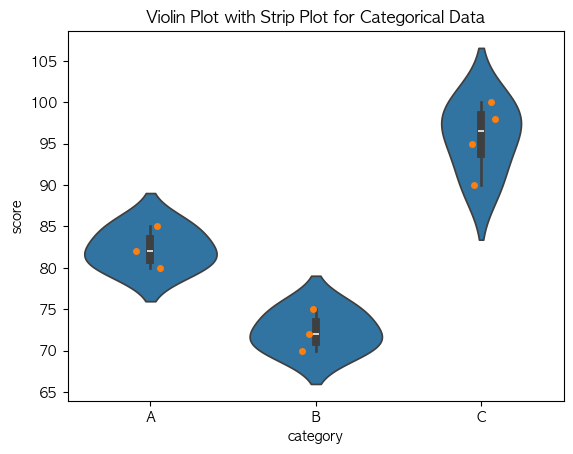

In [34]:
sns.violinplot(x="category", y="score", data=data)
sns.stripplot(x="category", y="score", data=data, jitter=True)
plt.title("Violin Plot with Strip Plot for Categorical Data")

plt.show()

#### 2.2 Continuous Data

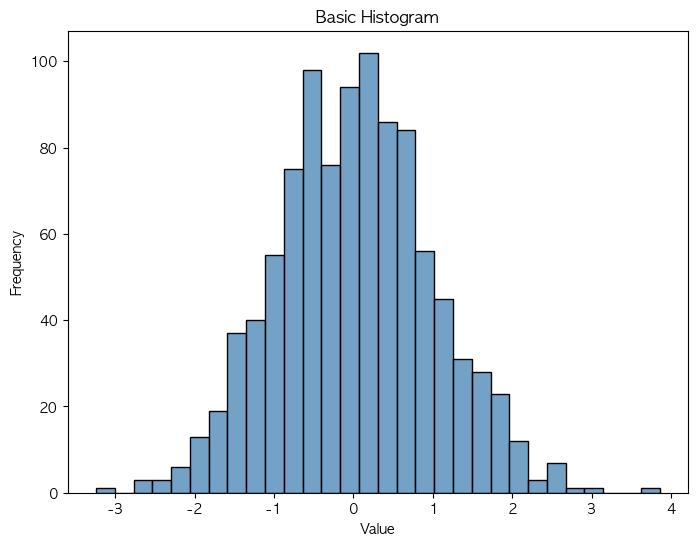

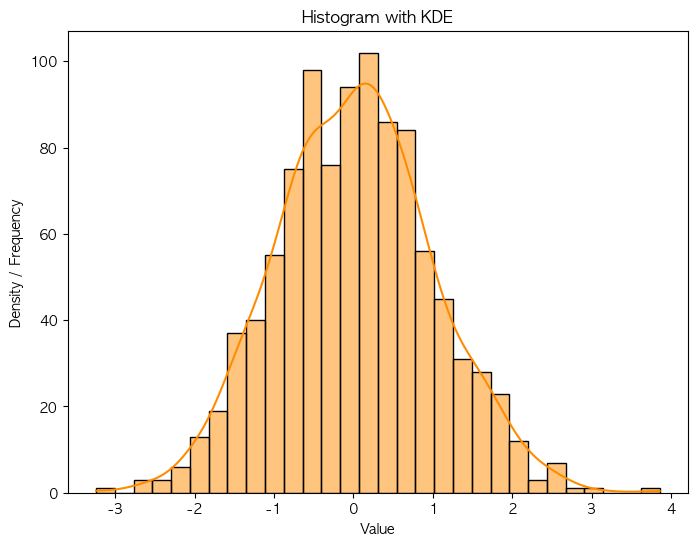

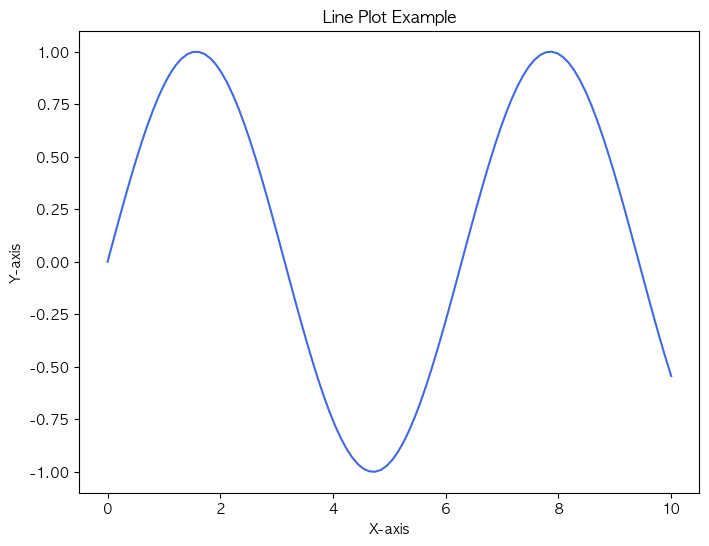

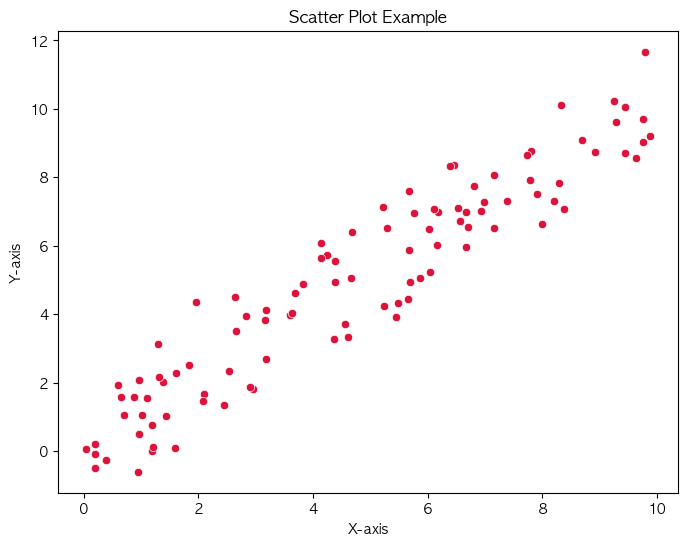

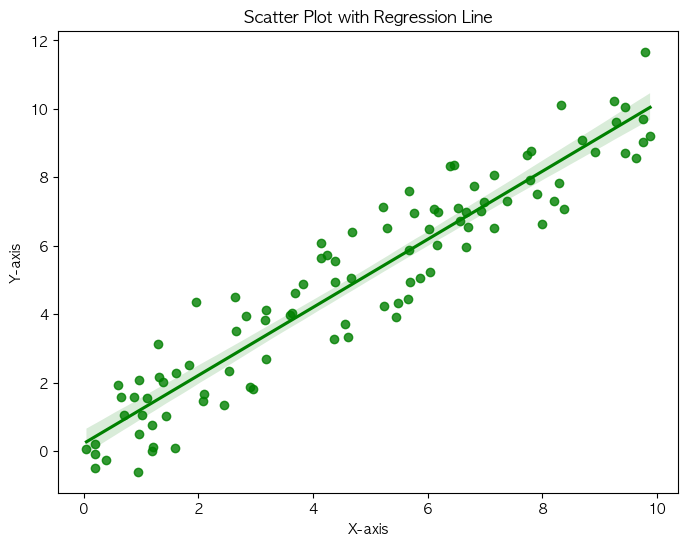

In [35]:
import seaborn as sns  # Seaborn 라이브러리 불러오기
import numpy as np  # 수학 연산 및 난수 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 그래프 출력을 위한 Matplotlib 불러오기

# 연속형 데이터 생성 (정규 분포를 따르는 데이터)
np.random.seed(42)  # 난수 생성 고정 (재현 가능성 보장)
data = np.random.randn(1000)  # 평균 0, 표준편차 1을 따르는 난수 1000개 생성

# 기본 히스토그램 생성
plt.figure(figsize=(8, 6))  # 그래프 크기 설정
sns.histplot(data, bins=30, color='steelblue')  # 히스토그램 생성

# 그래프 설정
plt.xlabel("Value")  # X축 라벨 설정
plt.ylabel("Frequency")  # Y축 라벨 설정
plt.title("Basic Histogram")  # 그래프 제목 설정

# 그래프 출력
plt.show()

# 히스토그램 + KDE 그래프 생성
plt.figure(figsize=(8, 6))
sns.histplot(data, bins=30, kde=True, color='darkorange')  # kde=True 옵션 추가

# 그래프 설정
plt.xlabel("Value")
plt.ylabel("Density / Frequency")
plt.title("Histogram with KDE")

# 그래프 출력
plt.show()

# 시계열 데이터 생성
x = np.linspace(0, 10, 100)  # 0부터 10까지 100개의 균등한 값 생성
y = np.sin(x)  # 사인 함수 값 생성

# 선 그래프 생성
plt.figure(figsize=(8, 6))
sns.lineplot(x=x, y=y, color='royalblue')

# 그래프 설정
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Line Plot Example")

# 그래프 출력
plt.show()

# 연속형 데이터 생성
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이의 난수 생성
y = x + np.random.randn(100)  # x와 비슷한 패턴을 가지면서 약간의 변동 추가

# 산점도 생성
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='crimson')

# 그래프 설정
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot Example")

# 그래프 출력
plt.show()

# 산점도 + 회귀선 추가
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, color='green')

# 그래프 설정
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot with Regression Line")

# 그래프 출력
plt.show()

1. 평균 0, 표준편차 1을 따르는 정규 분포 데이터를 500개 생성한 후, 히스토그램과 KDE를 함께 시각화하는 코드를 작성하세요.

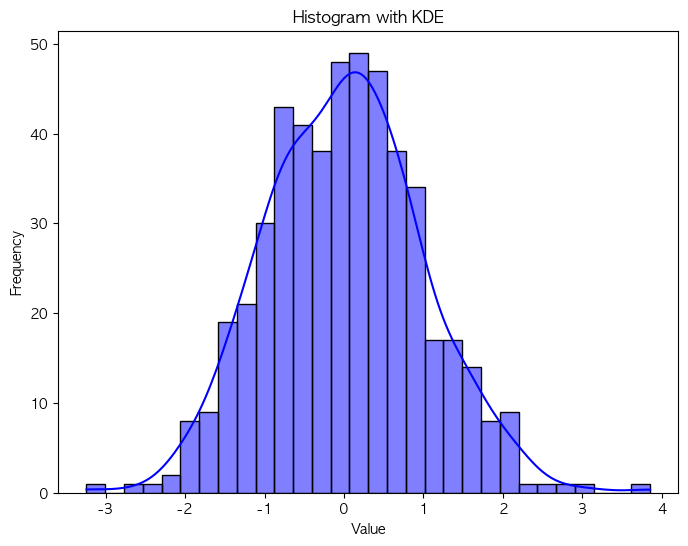

In [36]:
# 정규 분포를 따르는 데이터 생성
np.random.seed(42)
data = np.random.randn(500)

plt.figure(figsize=(8, 6))
sns.histplot(data, bins=30, kde=True, color='blue')

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with KDE")

plt.show()

2. 0부터 20까지 균등한 간격으로 생성된 데이터를 사용하여, 사인 함수의 선 그래프를 그리는 코드를 작성하세요.

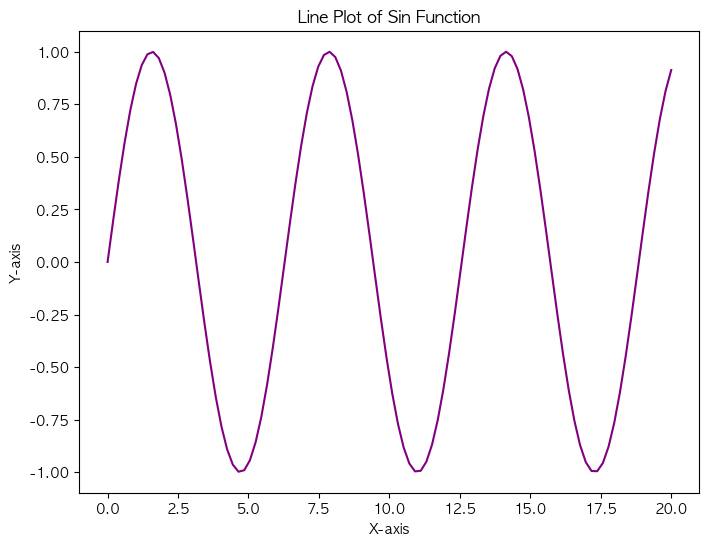

In [37]:
# X 값 생성 (0부터 20까지 100개의 균등한 값)
x = np.linspace(0, 20, 100)
y = np.sin(x)

plt.figure(figsize=(8, 6))
sns.lineplot(x=x, y=y, color='purple')

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Line Plot of Sin Function")

plt.show()

3. 랜덤한 100개의 연속형 데이터를 생성하여, 산점도와 회귀선을 포함한 그래프를 그리는 코드를 작성하세요.

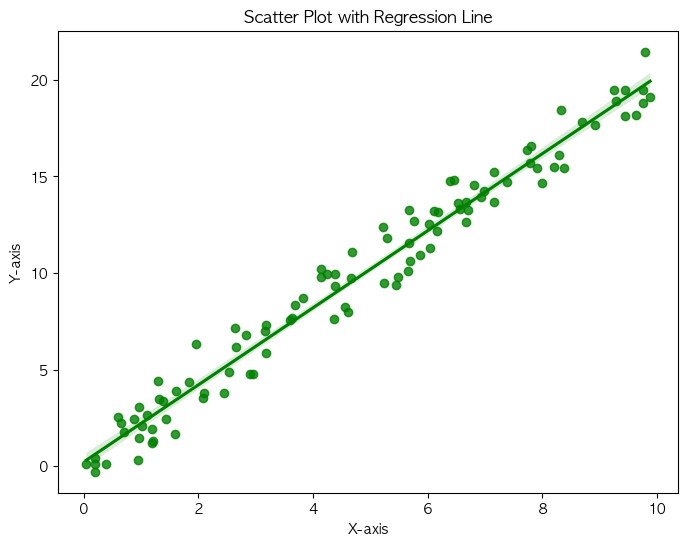

In [38]:
# 난수 생성 (재현 가능성 유지)
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이 난수
y = 2 * x + np.random.randn(100)  # x와 비례하는 관계, 약간의 변동 추가

plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, color='green')

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot with Regression Line")

plt.show()

#### 2.3 Relational Data

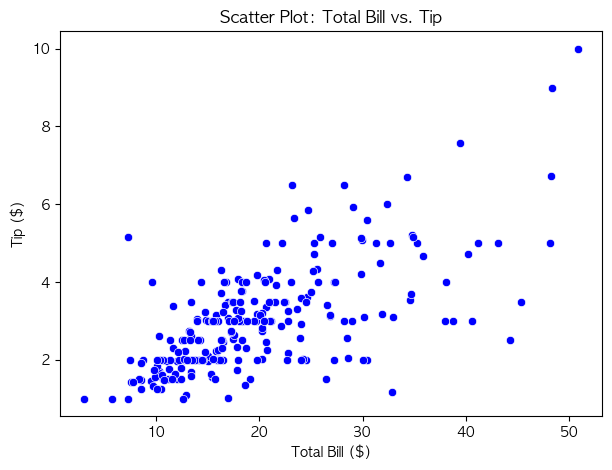

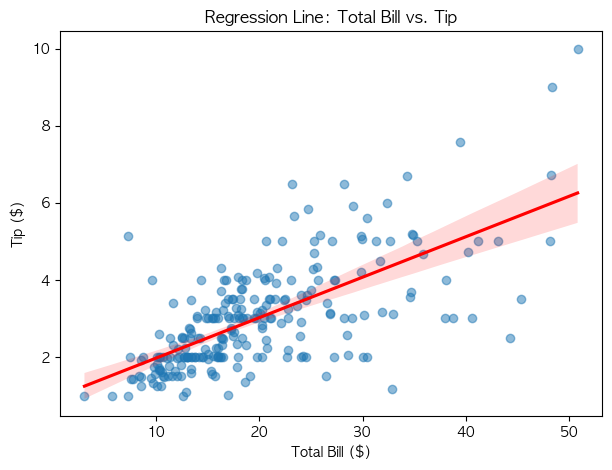

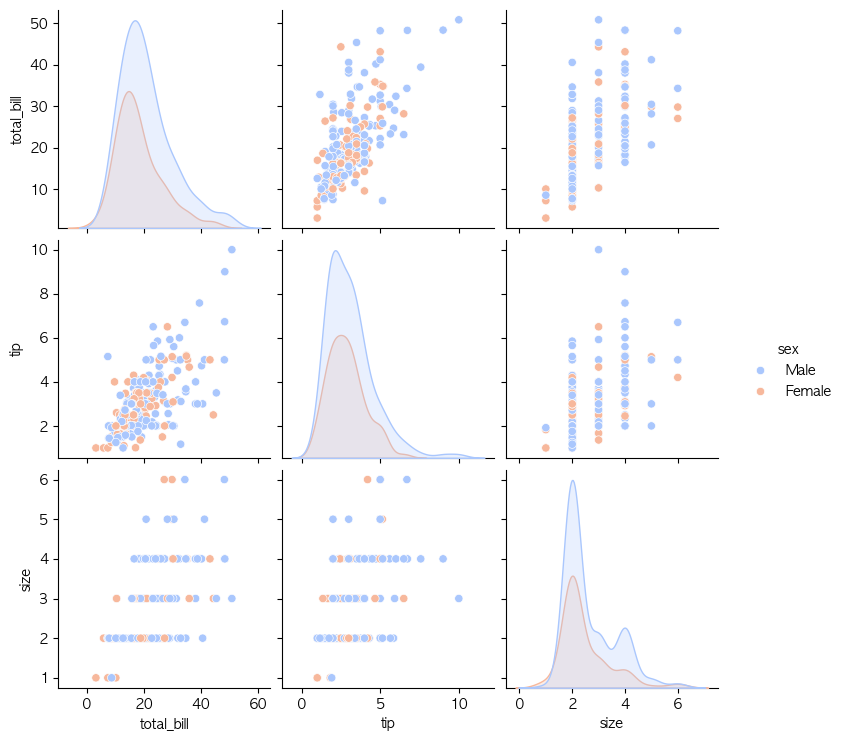

In [39]:
# 라이브러리 불러오기
import seaborn as sns  # Seaborn 라이브러리 (관계 데이터 시각화를 위한 라이브러리)
import matplotlib.pyplot as plt  # 그래프 출력을 위한 Matplotlib 라이브러리
import pandas as pd  # 데이터프레임 생성 및 처리
import numpy as np  # 수치 연산을 위한 NumPy 라이브러리

# 예제 데이터 로드 (Seaborn 내장 데이터셋: tips)
tips = sns.load_dataset("tips")  # 식당 팁 데이터셋 로드

# 기본 산점도 (total_bill과 tip의 관계)
plt.figure(figsize=(7, 5))  # 그래프 크기 설정
sns.scatterplot(x="total_bill", y="tip", data=tips, color="blue")  # X축은 총 금액, Y축은 팁
plt.title("Scatter Plot: Total Bill vs. Tip")  # 그래프 제목 설정
plt.xlabel("Total Bill ($)")  # X축 라벨 설정
plt.ylabel("Tip ($)")  # Y축 라벨 설정

# 그래프 출력
plt.show()

plt.figure(figsize=(7, 5))  # 그래프 크기 설정
sns.regplot(x="total_bill", y="tip", data=tips, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Regression Line: Total Bill vs. Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# sns.pairplot(): 여러 변수 간의 관계를 한 번에 시각화하는 함수입니다.
# vars=["total_bill", "tip", "size"]: 분석할 변수를 지정합니다.
# hue="sex": 성별(sex)에 따라 색상을 다르게 지정합니다.
# palette="coolwarm": 색상 테마를 적용합니다.
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="sex", palette="coolwarm")
plt.show()

1. Seaborn의 `scatterplot`을 활용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계를 시각화하는 코드를 작성하세요.

단, `scatterplot`의 색상과 스타일을 다르게 설정하여 출력해야 합니다.

In [40]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


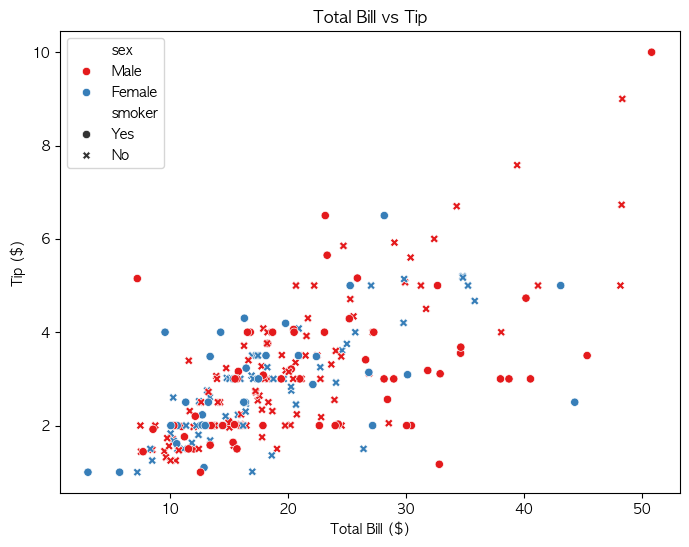

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="total_bill", y="tip", data=tips,
                hue="sex", style="smoker", palette="Set1")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

2. `sns.regplot`을 사용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계를 나타내는 회귀선 그래프를 그리고, 산점도의 투명도를 조정하는 코드를 작성하세요.

**단, 산점도에서 특정 성별(`sex`)만 필터링하여 표시해야 합니다.**

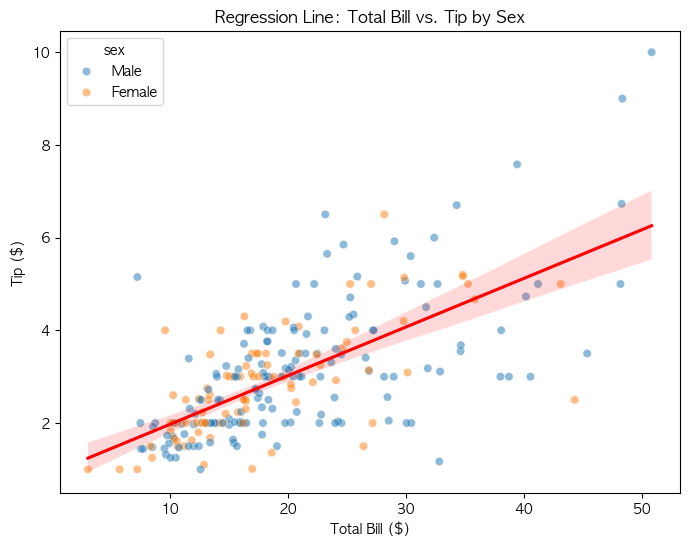

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="total_bill", y="tip", data=tips, hue="sex", alpha=0.5)
sns.regplot(x="total_bill", y="tip", data=tips, scatter=False, line_kws={'color': 'red'})

plt.title("Regression Line: Total Bill vs. Tip by Sex")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")

plt.show()

3. `sns.pairplot`을 사용하여 다중 변수(`total_bill`, `tip`, `size`) 간의 관계를 성별(`sex`)과 요일(`day`)에 따라 시각화하는 코드를 작성하세요.

단, 요일(`day`)에 따라 다른 색상을 적용해야 합니다.

<Figure size 800x600 with 0 Axes>

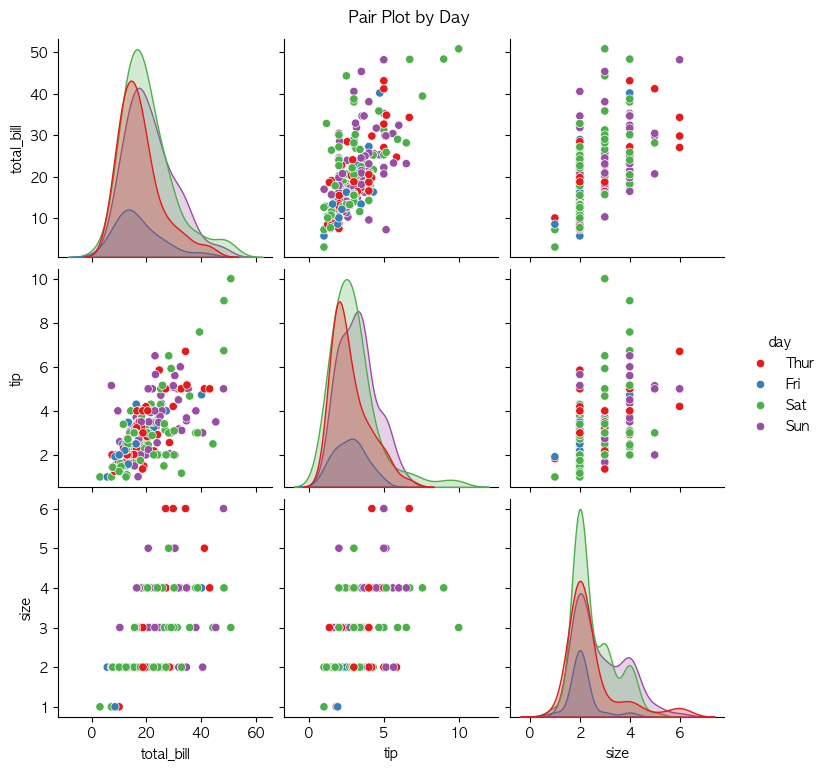

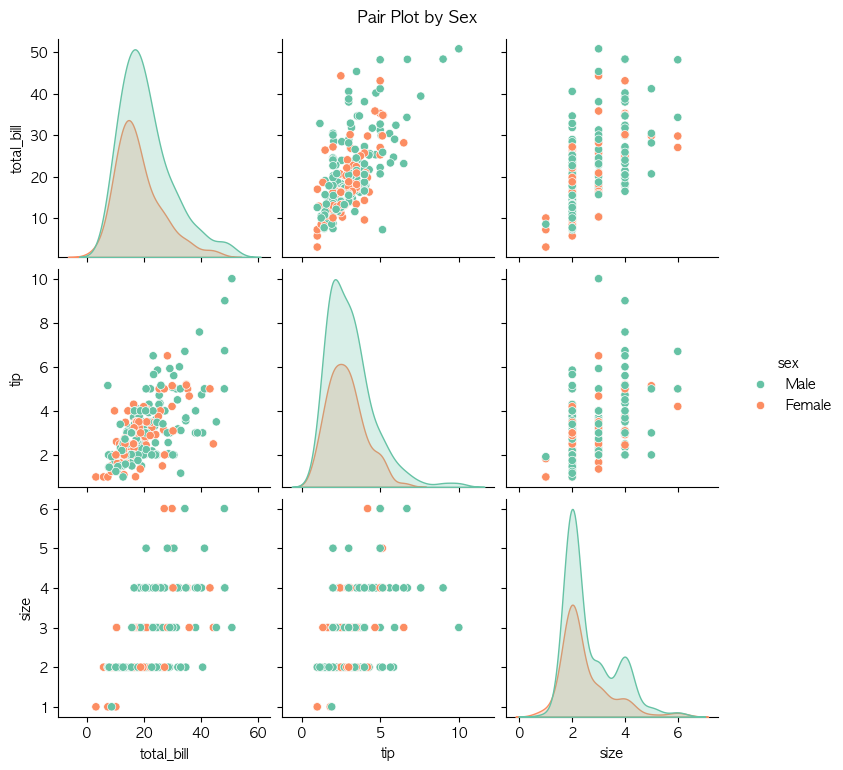

In [43]:
plt.figure(figsize=(8, 6))

# 요일별 색상 pairplot
g1 = sns.pairplot(tips, vars=["total_bill", "tip", "size"],
                hue="day", palette="Set1")
g1.fig.suptitle("Pair Plot by Day", y=1.02)
plt.show()

# 성별 pairplot (별도 figure)
g2 = sns.pairplot(tips, vars=["total_bill", "tip", "size"],
                hue="sex", palette="Set2")
g2.fig.suptitle("Pair Plot by Sex", y=1.02)
plt.show()


#### 2.4 Time Series Data

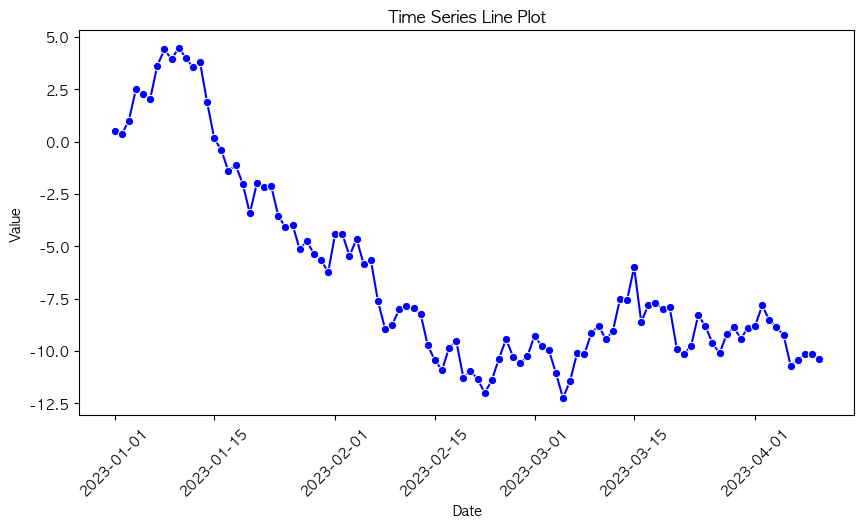

In [44]:
# 필수 라이브러리 불러오기
import seaborn as sns  # Seaborn 라이브러리 (데이터 시각화)
import pandas as pd  # Pandas (데이터프레임 처리)
import numpy as np  # NumPy (수학 연산 및 난수 생성)
import matplotlib.pyplot as plt  # Matplotlib (그래프 출력)

# 예제 시계열 데이터 생성
np.random.seed(42)  # 난수 생성 시드 고정 (재현성 유지)
# 2023년 1월 1일부터 100일간 날짜 생성
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
#  cumsum() : 배열의 누적합(cumulative sum)을 계산하는 NumPy 함수
data = np.cumsum(np.random.randn(100))  # 랜덤 데이터 생성 (누적합 적용)

# 데이터프레임으로 변환
df = pd.DataFrame({"Date": date_range, "Value": data})  # 날짜와 값을 포함한 데이터프레임 생성

# 선 그래프 시각화
plt.figure(figsize=(10, 5))  # 그래프 크기 설정
sns.lineplot(x="Date", y="Value", data=df, color="blue", marker="o")  # 시계열 선 그래프
plt.xlabel("Date")  # X축 라벨 설정
plt.ylabel("Value")  # Y축 라벨 설정
plt.title("Time Series Line Plot")  # 그래프 제목 설정
plt.xticks(rotation=45)  # X축 눈금 회전
plt.show()  # 그래프 출력

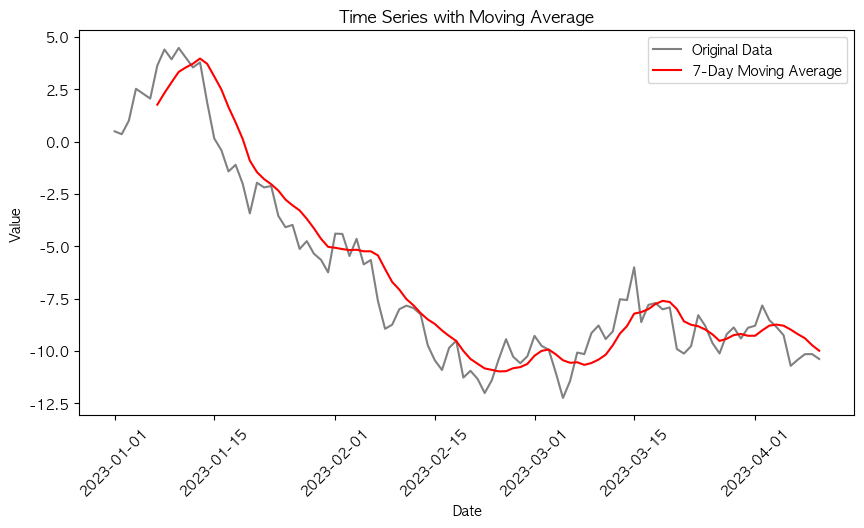

In [45]:
# 이동 평균(7일 평균) 계산
df["Moving_Avg"] = df["Value"].rolling(window=7).mean()  # 7일 이동 평균을 계산하여 새로운 컬럼 Moving_Avg에 저장

# 이동 평균 그래프 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="gray")  # 원본 데이터
sns.lineplot(x="Date", y="Moving_Avg", data=df, label="7-Day Moving Average", color="red")  # 이동 평균

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series with Moving Average")
plt.legend()  # 범례 추가
plt.xticks(rotation=45)
plt.show()

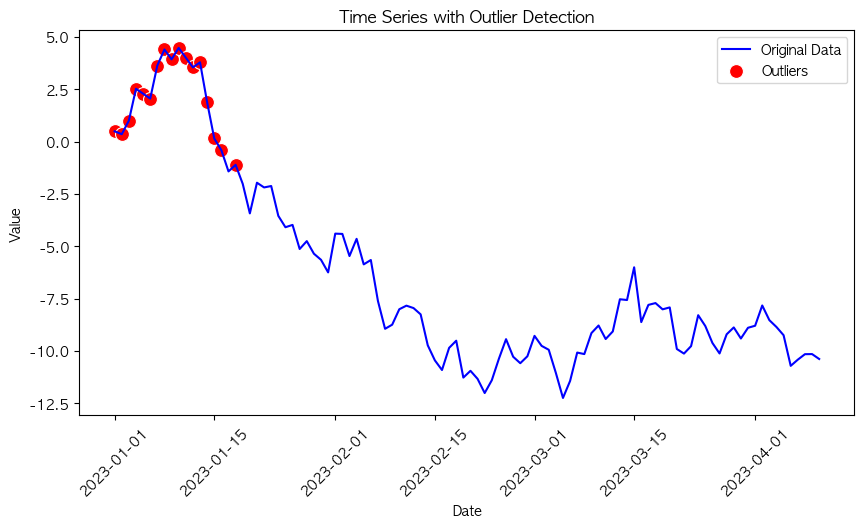

In [46]:
# 이상치 탐지를 위한 사분위 범위(IQR) 계산
Q1 = df["Value"].quantile(0.25)  # 1사분위수
Q3 = df["Value"].quantile(0.75)  # 3사분위수
IQR = Q3 - Q1  # IQR 계산
k = 0.5 # 이상치를 판별할 때 경계를 얼마나 넓게 잡을지 결정하는 값
lower_bound = Q1 - k * IQR  # 하한선
upper_bound = Q3 + k * IQR  # 상한선

# 이상치 여부 판별
df["Outlier"] = (df["Value"] < lower_bound) | (df["Value"] > upper_bound)  # 이상치 여부 (True/False)

# 이상치 데이터 필터링
outliers = df[df["Outlier"]]

# 이상치 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="blue")
sns.scatterplot(x="Date", y="Value", data=outliers, color="red", label="Outliers", s=100)  # 이상치 표시

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series with Outlier Detection")
plt.legend()
plt.xticks(rotation=45)
plt.show()

1. 100일간의 시계열 데이터를 생성하고, 이를 선 그래프로 시각화하는 코드를 작성하세요.

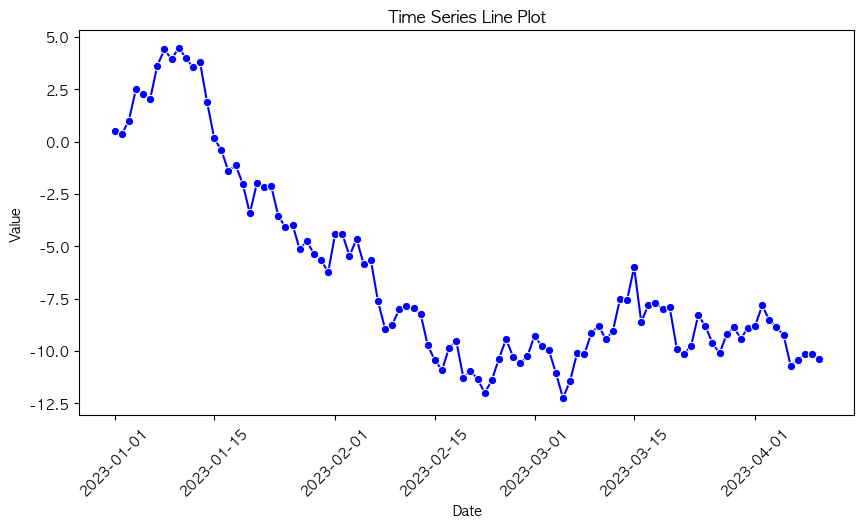

In [47]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
values = np.cumsum(np.random.randn(100))  # 랜덤 값의 누적합

df = pd.DataFrame({"Date": date_range, "Value": values})  # 날짜와 값을 포함한 데이터프레임 생성

# 선 그래프 시각화
plt.figure(figsize=(10, 5))  # 그래프 크기 설정
sns.lineplot(x="Date", y="Value", data=df, color="blue", marker="o")  # 시계열 선 그래프
plt.xlabel("Date")  # X축 라벨 설정
plt.ylabel("Value")  # Y축 라벨 설정
plt.title("Time Series Line Plot")  # 그래프 제목 설정
plt.xticks(rotation=45)  # X축 눈금 회전
plt.show()  # 그래프 출력


2. 1번 퀘스트에서 생성한 데이터를 기반으로 7일 이동 평균을 계산하고, 원본 데이터와 함께 그래프로 비교하는 코드를 작성하세요.

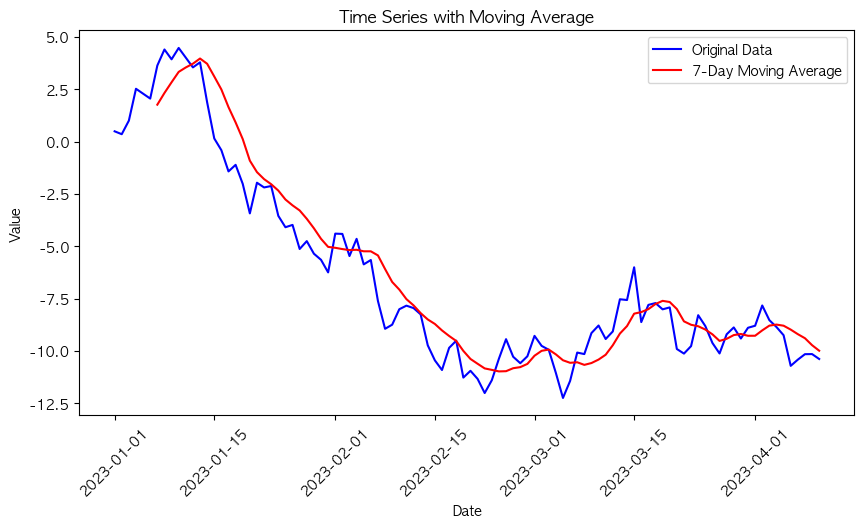

In [48]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({"Date": date_range, "Value": values})
df['Moving_Avg'] = df['Value'].rolling(window=7).mean()  # 7일 이동 평균 계산

plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="blue")  # 원본 데이터
sns.lineplot(x="Date", y="Moving_Avg", data=df, label="7-Day Moving Average", color="red")  # 이동 평균

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series with Moving Average")
plt.legend()
plt.xticks(rotation=45)  # X축 눈금 회전

plt.show()

3. **1번 퀘스트에서 생성한 시계열 데이터에서 이상치를 탐지하고, 이상치만 강조하여 그래프에 표시하는 코드**를 작성하세요.

이상치는 사분위수 범위(IQR)를 이용해 판단합니다.

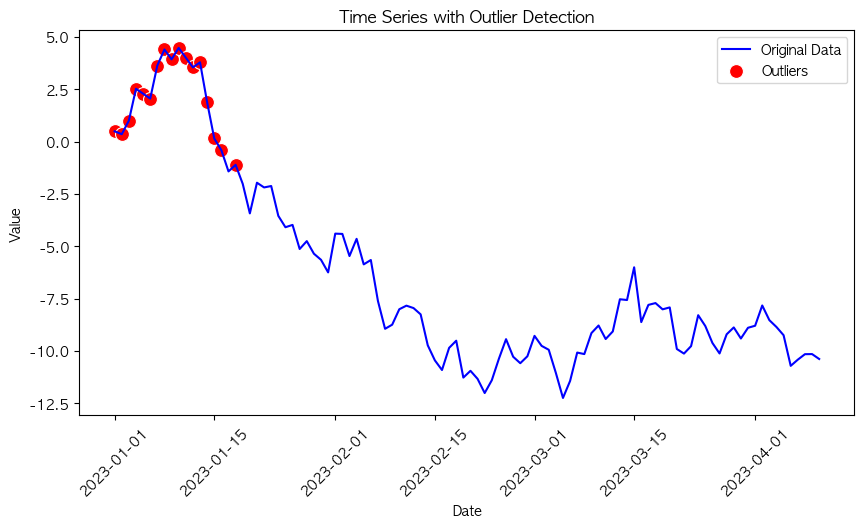

In [49]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({"Date": date_range, "Value": values})

Q1 = df["Value"].quantile(0.25)
Q2 = df["Value"].quantile(0.5)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1
k = 0.5
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

df["Outlier"] = (df["Value"] < lower_bound) | (df["Value"] > upper_bound)
outliers = df[df["Outlier"]]

plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="blue")
sns.scatterplot(x="Date", y="Value", data=outliers, color="red", label="Outliers", s=100)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series with Outlier Detection")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### 2.5 Resampling

1. pandas를 사용하여 3시간 간격의 시계열 데이터를 생성한 후, 하루 단위(D)로 평균을 구하는 다운샘플링을 수행하는 코드를 작성하세요.

In [50]:
# 3시간 간격의 시계열 데이터 생성 (2024년 1월 1일부터 5일까지)
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

df = pd.DataFrame({
    "date": date_rng,
    'value': np.random.randint(10, 100, size=len(date_rng))  
})

df.set_index("date", inplace=True)

# 데이터 확인
df.head().reset_index()

,date,value
0,2024-01-01 00:00:00,18
1,2024-01-01 03:00:00,71
2,2024-01-01 06:00:00,46
3,2024-01-01 09:00:00,60
4,2024-01-01 12:00:00,53


In [51]:
# 다운샘플링
df_daily = df.resample('D').mean()  # 일별 평균으로 다운샘플링

# 다운샘플링된 데이터 확인
df_daily.head().reset_index()

,date,value
0,2024-01-01,54.625
1,2024-01-02,58.375
2,2024-01-03,41.375
3,2024-01-04,50.000
4,2024-01-05,79.000


2. 3시간 간격으로 생성된 시계열 데이터에서 1시간 단위로 업샘플링한 후, 선형 보간(linear)을 적용하는 코드를 작성하세요.

In [52]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-03", freq="3h")

df = pd.DataFrame({
    "date": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))
})

df.set_index("date", inplace=True)

# 기존 데이터 확인
df.head().reset_index()

,date,value
0,2024-01-01 00:00:00,41
1,2024-01-01 03:00:00,77
2,2024-01-01 06:00:00,64
3,2024-01-01 09:00:00,84
4,2024-01-01 12:00:00,65


In [53]:
# 업샘플링
df_hourly = df.resample("h").asfreq()

# 선형 보간 적용
df_hourly = df_hourly.interpolate(method='linear')

# 업샘플링된 데이터 확인
df_hourly.head().reset_index()

,date,value
0,2024-01-01 00:00:00,41.000000
1,2024-01-01 01:00:00,53.000000
2,2024-01-01 02:00:00,65.000000
3,2024-01-01 03:00:00,77.000000
4,2024-01-01 04:00:00,72.666667


3. 3시간 간격으로 생성된 시계열 데이터에서 하루 단위(D)로 다운샘플링을 수행한 후, 각 날짜에 해당하는 최소(min) 값과 최대(max) 값을 출력하는 코드를 작성하세요.

In [54]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-07", freq="3h")

df = pd.DataFrame({
    "date": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))
})

df.set_index("date", inplace=True)

# 기존 데이터 확인
df.describe()

,value
count,49.000000
mean,48.734694
std,26.687837
min,10.000000
25%,28.000000
50%,45.000000
75%,68.000000
max,99.000000


In [55]:
# 다운샘플링: 일별 평균, 최솟값, 최댓값
df_daily = df.resample('D').agg(["mean", "min", "max"])
df_daily.columns = ["mean_value", "min_value", "max_value"]

df_daily.reset_index()

,date,mean_value,min_value,max_value
0,2024-01-01,48.125,12,99
1,2024-01-02,51.250,10,91
2,2024-01-03,47.750,16,98
3,2024-01-04,46.250,10,99
4,2024-01-05,40.000,12,89
5,2024-01-06,53.500,33,84
6,2024-01-07,93.000,93,93


#### 2.6 Moving Average

1. 주어진 시계열 데이터에서 7일 단순 이동평균(SMA) 을 계산하여 새로운 컬럼을 추가하는 코드를 작성하세요.

In [56]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})


# 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,  # 날짜 데이터를 'datetime' 컬럼으로 저장
    "value": np.random.randint(50, 150, size=len(date_rng))  # 50~150 사이의 랜덤 값 생성
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 데이터 확인 (reset_index 적용)
df.head().reset_index()

,datetime,value
0,2024-01-01,69
1,2024-01-02,57
2,2024-01-03,56
3,2024-01-04,116
4,2024-01-05,66


In [57]:
# 7일 단위 단순 이동평균 적용
df["SMA_7"] = df["value"].rolling(window=7).mean()

# 데이터 확인 (reset_index 적용)
df.head(10).reset_index()

,datetime,value,SMA_7
0,2024-01-01,69,NaN
1,2024-01-02,57,NaN
2,2024-01-03,56,NaN
3,2024-01-04,116,NaN
4,2024-01-05,66,NaN
5,2024-01-06,82,NaN
6,2024-01-07,97,77.571429
7,2024-01-08,125,85.571429
8,2024-01-09,108,92.857143
9,2024-01-10,135,104.142857


2. 시계열 데이터에서 7일 지수 이동평균(EMA) 을 계산하고, 기존 데이터와 비교하여 출력하는 코드를 작성하세요.

In [58]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 데이터 확인 (reset_index 적용)
df.head().reset_index()

,datetime,value
0,2024-01-01,79
1,2024-01-02,146
2,2024-01-03,77
3,2024-01-04,113
4,2024-01-05,146


In [59]:
# 7일 단위 지수 이동평균 적용
df["EMA_7"] = df["value"].ewm(span=7, adjust=False).mean()

# 데이터 확인 (reset_index 적용)
df.head(10).reset_index()

,datetime,value,EMA_7
0,2024-01-01,79,79.000000
1,2024-01-02,146,95.750000
2,2024-01-03,77,91.062500
3,2024-01-04,113,96.546875
4,2024-01-05,146,108.910156
5,2024-01-06,118,111.182617
6,2024-01-07,110,110.886963
7,2024-01-08,97,107.415222
8,2024-01-09,68,97.561417
9,2024-01-10,53,86.421062


3. 주어진 시계열 데이터에서 **이동평균을 활용하여 변동성이 큰 날을 탐색하는 코드**를 작성하세요.

**7일 단순 이동평균(SMA)과 비교하여 특정 일자의 값이 이동평균보다 ±20% 이상 차이가 나는 경우만 출력**하세요.

In [60]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 7일 단위 단순 이동평균 적용
df["SMA_7"] = df["value"].rolling(window=7).mean()

# 데이터 확인 (reset_index 적용)
df.head(10).reset_index()

,datetime,value,SMA_7
0,2024-01-01,148,NaN
1,2024-01-02,86,NaN
2,2024-01-03,73,NaN
3,2024-01-04,142,NaN
4,2024-01-05,95,NaN
5,2024-01-06,102,NaN
6,2024-01-07,144,112.857143
7,2024-01-08,148,112.857143
8,2024-01-09,109,116.142857
9,2024-01-10,146,126.571429


In [61]:
df_clean = df.dropna(subset=['SMA_7'])

volatile = df_clean[
    (df_clean['value'] >= df_clean['SMA_7'] * 1.2) |
    (df_clean['SMA_7'] >= df_clean['value'] * 1.2)
]

volatile.reset_index()

,datetime,value,SMA_7
0,2024-01-07,144,112.857143
1,2024-01-08,148,112.857143
2,2024-01-13,81,124.857143
3,2024-01-15,82,114.285714
4,2024-01-17,67,104.000000
5,2024-01-18,74,98.571429
6,2024-01-19,144,100.000000


#### 2.7 Financial Data

1. 샘플 금융 데이터프레임을 직접 생성한 후, 데이터의 기본 정보(행 개수, 열 개수, 데이터 타입 등)를 출력하는 코드를 작성하세요.

In [62]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}

df = pd.DataFrame(data)

df.describe()

,Date,Open,High,Low,Close,Volume
count,10,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2024-01-05 12:00:00,108.000000,110.600000,106.000000,109.200000,1540.000000
min,2024-01-01 00:00:00,100.000000,102.000000,98.000000,101.000000,1000.000000
25%,2024-01-03 06:00:00,103.500000,107.250000,101.500000,105.250000,1325.000000
50%,2024-01-05 12:00:00,107.500000,109.500000,105.500000,108.500000,1550.000000
75%,2024-01-07 18:00:00,111.500000,114.250000,109.500000,112.500000,1775.000000
max,2024-01-10 00:00:00,118.000000,120.000000,116.000000,119.000000,2000.000000
std,NaN,5.811865,5.460973,5.811865,5.613476,320.416396


2. 주어진 df 데이터프레임에서 5일 이동평균(SMA)과 5일 지수 이동평균(EMA)을 계산하는 코드를 작성하세요.

In [63]:
# 퀘스트 2 답안은 아래 셀에서 확인 (Close 컬럼 기준, window=5)

In [64]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}

df = pd.DataFrame(data)

df['SMA'] = df['Close'].rolling(window=5).mean()
df['EWA'] = df['Close'].ewm(span=5, adjust=False).mean()

df

,Date,Close,SMA,EWA
0,2024-01-01,101,NaN,101.000000
1,2024-01-02,104,NaN,102.000000
2,2024-01-03,106,NaN,103.333333
3,2024-01-04,105,NaN,103.888889
4,2024-01-05,109,105.0,105.592593
5,2024-01-06,108,106.4,106.395062
6,2024-01-07,111,107.8,107.930041
7,2024-01-08,113,109.2,109.620027
8,2024-01-09,116,111.4,111.746685
9,2024-01-10,119,113.4,114.164457


3. df 데이터프레임에서 주간(7일) 단위로 종가(Close) 평균을 리샘플링한 후, 이를 바탕으로 주간 변동성(표준편차)을 계산하는 코드를 작성하세요.

In [65]:
# 샘플 금융 데이터 생성 (30일치)
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))  # 100~200 사이의 랜덤 종가 생성

df = pd.DataFrame({
    "date": date_rng,
    "value": close_prices
})

df.set_index("date", inplace=True)

df.head()

,value
date,
2024-01-01,169.602980
2024-01-02,157.006117
2024-01-03,109.717649
2024-01-04,161.500723
2024-01-05,199.005385


In [66]:
# 업샘플링 및 변동성 확인
df_weekly = df["value"].resample("W").agg(["mean", "std"])
df_weekly.columns = ["weekly_close_mean", "weekly_volatility"]

df_weekly

,weekly_close_mean,weekly_volatility
date,,
2024-01-07,151.810603,31.266680
2024-01-14,164.001224,22.398749
2024-01-21,172.164915,16.801879
2024-01-28,153.908644,28.354819
2024-02-04,125.077015,30.381249


### 3. Scipy

#### 3.1 Normal Distribution

1. 평균 60, 표준 편차 15를 갖는 정규 분포에서 500개의 데이터를 생성한 후, 데이터의 기본 통계 정보(평균, 표준 편차, 최소값, 최대값)를 출력하는 코드를 작성하세요.

In [67]:
# 평균 60, 표준 편차 15인 정규 분포에서 500개의 난수 생성
data = np.random.normal(loc=60, scale=15, size=500)

df = pd.DataFrame({'value':data})

df.describe()

,value
count,500.000000
mean,60.389209
std,15.606108
min,18.885677
25%,50.608114
50%,60.096342
75%,71.609954
max,101.756661


2. 평균 50, 표준 편차 10을 갖는 정규 분포에서 특정 값 x=65의 확률 밀도 함수(PDF) 값을 계산하고 출력하는 코드를 작성하세요.

In [68]:
x_value = 65  # 퀘스트 조건: x=65
pdf_value = stats.norm.pdf(x_value, loc=50, scale=10)

print(f"x={x_value}의 PDF 값: {pdf_value:.6f}")

x=65의 PDF 값: 0.012952


3. 평균 70, 표준 편차 8을 갖는 정규 분포에서 (1) 특정 값 x=80 이하일 확률을 CDF로 계산하고, (2) 상위 5%에 해당하는 점수를 PPF로 계산하여 출력하는 코드를 작성하세요.

In [69]:
x_value = 80
cdf_value = stats.norm.cdf(x_value, loc=70, scale=8)
ppf_value = stats.norm.ppf(0.95, loc=70, scale=8)

print("1. 특정 값 x=80 이하일 확률:", cdf_value)
print("2. 위 5%에 해당하는 점수:", ppf_value)

1. 특정 값 x=80 이하일 확률: 0.8943502263331446
2. 위 5%에 해당하는 점수: 83.15882901561177


#### 3.2 Descriptive Statistics

1. 주어진 데이터에서 평균과 중앙값의 차이를 계산하는 코드를 작성하세요.

In [70]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

mean_value = np.mean(df['value'])
median_value = np.median(df['value'])

print("평균과 중앙값의 차이:", mean_value-median_value)

평균과 중앙값의 차이: 0.2310977438562034


2. **데이터에서 이상값(Outlier)을 찾아 제거한 후, 원래 데이터와 이상값 제거 후 데이터의 평균을 비교하는 코드**를 작성하세요.

이상값은 **IQR(사분위 범위)를 사용하여 탐지**하세요.

In [71]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

# IQR 활용하여 계산
q1 = np.percentile(df["value"], 25)  
q3 = np.percentile(df["value"], 75)
iqr = q3 - q1  

# 이상값 찾기
lower_bound = q1 - 1.5 * iqr  
upper_bound = q3 + 1.5 * iqr  

# 이상값 필터링
outliers = df[(df["value"] < lower_bound) | (df["value"] > upper_bound)]  # 값이 하한 또는 상한 경계를 벗어난 데이터 선택

# 결과 출력
print("이상값 개수:", len(outliers)) 
outliers.reset_index()

이상값 개수: 1


,index,value
0,74,23.802549


3. 데이터의 왜도(Skewness)와 첨도(Kurtosis)를 계산하여 데이터의 분포 특성을 분석하는 코드를 작성하세요.

In [72]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

skewness = stats.skew(df['value'])
kurtosis = stats.kurtosis(df['value'])

print(f"왜도: {skewness}") 
print(f"첨도: {kurtosis}")  

왜도: -0.17526772024434067
첨도: -0.15540470774207948


#### 3.3 Hypothesis Testing

1. **단일 표본 t-검정(One-Sample t-test)** 을 수행하여 샘플 데이터의 평균이 특정 값과 유의미한 차이가 있는지 검정하는 코드를 작성하세요.

(평균 `50`, 표준 편차 `5`를 따르는 정규 분포에서 30개의 데이터를 생성하고, 해당 데이터가 평균 `52`와 차이가 있는지 확인하세요.)

In [73]:
# 샘플 데이터 생성
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)

# 단일 표본 t-검정: 표본 평균이 52와 유의미하게 다른지
t_stat, p_value = stats.ttest_1samp(sample_data, 52)

print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_value:.4f}")
if p_value < 0.05:
    print("→ 유의수준 0.05에서 표본 평균이 52와 유의미하게 다릅니다.")
else:
    print("→ 표본 평균이 52와 유의미한 차이가 없습니다.")

t-통계량: -3.5793
p-값: 0.0012
→ 유의수준 0.05에서 표본 평균이 52와 유의미하게 다릅니다.


2. 카이제곱 검정(Chi-Square Test) 을 수행하여 관측된 데이터와 기대값이 유의미한 차이가 있는지 확인하는 코드를 작성하세요.

In [74]:
# 관측된 데이터 (Observed)
observed = np.array([50, 60, 90])

# 기대값: 전체 합을 균등 분배
expected = np.full(3, observed.sum() / 3)

chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-값: {p_value:.4f}")

카이제곱 통계량: 13.0000
p-값: 0.0015


3. **분산 분석(ANOVA, Analysis of Variance)** 을 수행하여 여러 그룹의 평균이 서로 다른지 검정하는 코드를 작성하세요.

In [75]:
# 샘플 데이터 생성
np.random.seed(42)
group_1 = np.random.normal(loc=50, scale=10, size=30)
group_2 = np.random.normal(loc=55, scale=10, size=30)
group_3 = np.random.normal(loc=60, scale=10, size=30)

f_stat, p_value = stats.f_oneway(group_1, group_2, group_3)

print(f"F-통계량: {f_stat:.4f}")
print(f"p-값: {p_value:.4f}")
if p_value < 0.05:
    print("유의수준 0.05에서 그룹 간 평균 차이가 유의미합니다.")
else:
    print("그룹 간 평균 차이가 유의미하지 않습니다.")

F-통계량: 12.2095
p-값: 0.0000
유의수준 0.05에서 그룹 간 평균 차이가 유의미합니다.


#### 3.4 Statistical Visualization

1. NumPy를 사용하여 평균 70, 표준편차 20을 따르는 정규 분포 데이터 1000개를 생성한 후, Matplotlib을 활용하여 박스플롯을 그리는 코드를 작성하세요.

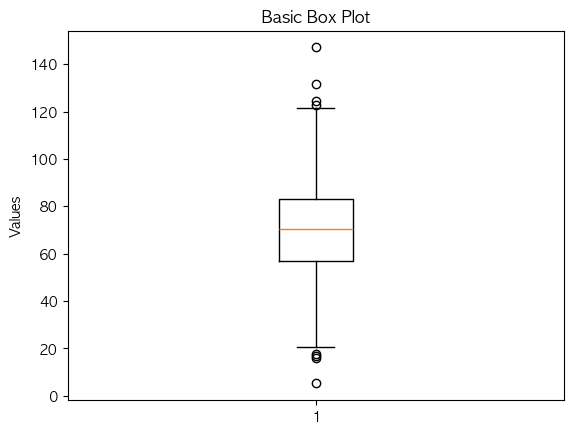

In [76]:
# 데이터 생성 (평균=70, 표준편차=20인 정규 분포 데이터 1000개)
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

plt.boxplot(data)
plt.title("Basic Box Plot")
plt.ylabel("Values")

plt.show()

2. 평균이 각각 55와 60이고, 표준편차가 8인 두 개의 그룹(A, B) 데이터를 생성한 후, **두 그룹의 데이터 분포를 Seaborn을 활용하여 KDE(커널 밀도 함수)와 함께 히스토그램으로 시각화**하세요.

이후, **두 그룹 간 평균 차이가 유의미한지 t-검정을 수행하는 코드**를 작성하세요.

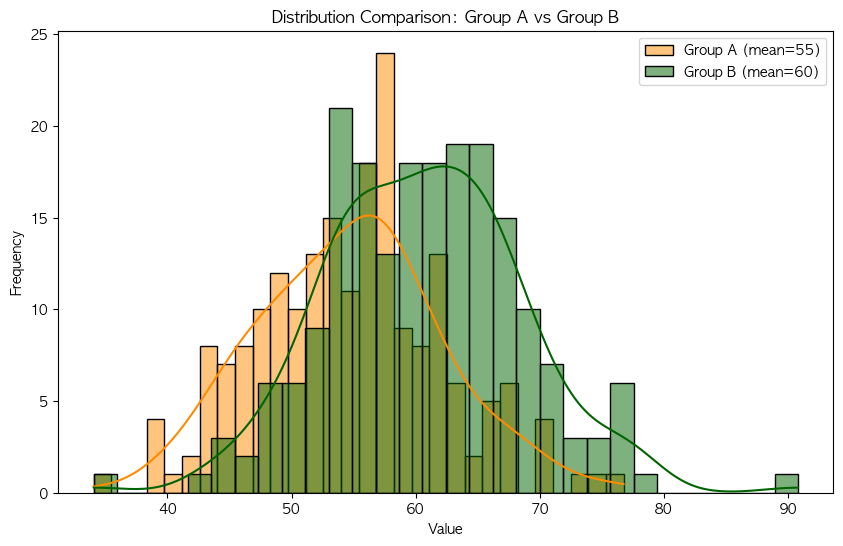

t-statistic: -7.8344
p-value: 0.0000
두 그룹의 평균 차이는 통계적으로 유의미합니다.


In [77]:
# 그래프 같이 보기
# 데이터 생성
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)
group_B = np.random.normal(loc=60, scale=8, size=200)

# KDE + 히스토그램
plt.figure(figsize=(10, 6))

sns.histplot( group_A, bins=30, kde=True, color="darkorange", label="Group A (mean=55)", alpha=0.5)
sns.histplot(group_B, bins=30, kde=True, color="darkgreen", label="Group B (mean=60)", alpha=0.5)

plt.title("Distribution Comparison: Group A vs Group B")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# t-검정
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("두 그룹의 평균 차이는 통계적으로 유의미합니다.")
else:
    print("두 그룹의 평균 차이는 통계적으로 유의미하지 않습니다.")

3. 광고 A를 본 500명 중 120명이 클릭하였고, 광고 B를 본 500명 중 150명이 클릭을 한 데이터가 있습니다.

이 데이터를 바탕으로 **카이제곱 검정을 수행하여 광고 A와 B의 클릭률 차이가 유의미한지 분석하고, Seaborn의 barplot을 사용하여 클릭률을 비교하는 그래프를 그리는 코드**를 작성하세요.

In [78]:
# 데이터 생성 (광고 A와 B의 클릭 여부)
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],  # 광고 A 클릭(120명) vs 미클릭(380명)
    "Ad_B": [150, 350]   # 광고 B 클릭(150명) vs 미클릭(350명)
}, index=["Click", "No Click"])


chi2, p_value, dof, expected = stats.chi2_contingency(observed_data)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("유의미한 차이 존재")
else:
    print("유의미한 차이 없음")


카이제곱 통계량: 4.2669
p-value: 0.0389
유의미한 차이 존재
